# Pagan Lab — Behavioral Data Demo

This notebook demonstrates how to stream and explore a Pagan Lab behavioral session directly from **[DANDI:001550](https://dandiarchive.org/dandiset/001550)**.

The example session is **TaskSwitch6, subject P100, 2019-04-23** — a multi-sensory decision-making task in which rats report whether an auditory stream is dominated by high-rate or low-rate clicks (direction) or high-pitched or low-pitched tones (frequency), switching between the two rules across blocks.

**Reference:** Pagan et al., *Nature* 639, 421–429 (2025). doi:10.1038/s41586-024-08433-6

In [64]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pynwb import NWBHDF5IO
from ndx_structured_behavior.plot import (
    plot_events,
    plot_actions,
    plot_states,
    compute_state_transition_matrix,
)
from dandi.dandiapi import DandiAPIClient
import remfile
import h5py

DANDISET_ID = "001550"
ASSET_PATH  = "sub-P100/sub-P100_ses-TaskSwitch6-190423a.nwb"

## 1. Stream the NWB file from DANDI

The session is fetched directly from the [DANDI Archive](https://dandiarchive.org/dandiset/001550) using byte-range HTTP requests — only the data you access is downloaded.

**Dependencies** (install once if needed):
```
pip install dandi remfile h5py
```

In [65]:
with DandiAPIClient() as client:
    asset = client.get_dandiset(DANDISET_ID, "draft").get_asset_by_path(ASSET_PATH)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

remote_file = remfile.File(s3_url)
h5_file     = h5py.File(remote_file, "r")
io          = NWBHDF5IO(file=h5_file, load_namespaces=True)
nwbfile     = io.read()

print(f"Session ID         : {nwbfile.session_id}")
print(f"Session start time : {nwbfile.session_start_time}")
print(f"Subject ID         : {nwbfile.subject.subject_id}")
print(f"Experimenter       : {nwbfile.experimenter}")
if nwbfile.notes:
    preview = nwbfile.notes[:300]
    suffix = "..." if len(nwbfile.notes) > 300 else ""
    print(f"Notes              :\n{preview}{suffix}")

Session ID         : TaskSwitch6-190423a
Session start time : 2019-04-23 11:30:00+01:00
Subject ID         : P100
Experimenter       : ('Pagan, Marino', 'Tang, Vincent D.')
Notes              :
*** 23-Apr-2019 ***

Stage 11 ;
days: 1 ;
valid: 467 ;
dir: 0.78 ;
freq: 0.77 ;
coh: 0.84 ;
incoh: 0.72


## 3. Task metadata

The `Task` object in `nwbfile.lab_meta_data["task"]` stores the vocabulary of states, events, and actions used in this session.

In [66]:
task = nwbfile.lab_meta_data["task"]

print("=== Event types (port pokes) ===")
display(task.event_types[:])

print("=== Action types (sounds / outputs) ===")
display(task.action_types[:])

print("=== State types ===")
display(task.state_types[:])

=== Event types (port pokes) ===


,event_name
id,
0,C
1,L
2,R


=== Action types (sounds / outputs) ===


,action_name
id,
0,direct_reward
1,stimulatorwave
2,cpoke_timer


=== State types ===


,state_name
id,
0,state_0
1,sending_trialnum
2,check_next_trial_ready
3,wait_for_cpoke
4,wait_for_cpoke_wait2
5,wait_for_cpoke_dir
6,wait_for_cpoke_freq
7,wait_for_cpoke_bis
8,nic_prestim


## 4. Behavioral data — Events, States, Actions

The `TaskRecording` in `nwbfile.acquisition["task_recording"]` holds the full time-series of events (port pokes), states, and actions (sounds/rewards). Each table row links back to the corresponding type table via a `DynamicTableRegion` index column.

### Events

![Events](events.png)

The `EventsTable` stores one row per port poke (enter + exit time). Each event links to `EventTypesTable` via an integer index.

### States

![States](states.png)

The `StatesTable` stores one row per state occurrence (`start_time` / `stop_time`). Each state links to `StateTypesTable`.

### Actions

![Actions](actions.png)

The `ActionsTable` stores one row per sound or output event (onset time + duration). Each action links to `ActionTypesTable`.

In [67]:
task_recording = nwbfile.acquisition["task_recording"]
events       = task_recording.events
states       = task_recording.states
actions      = task_recording.actions
event_types  = task.event_types
state_types  = task.state_types
action_types = task.action_types

print(f"Events  : {len(events)} rows")
print(f"States  : {len(states)} rows")
print(f"Actions : {len(actions)} rows")

print("\n--- Events (first 5) ---")
display(
    pd.merge(
        events[:5], event_types[:],
        left_on="event_type", right_on="id",
    )
)

print("--- States (first 5) ---")
display(
    pd.merge(
        states[:5], state_types[:],
        left_on="state_type", right_on="id",
    )
)

print("--- Actions (first 5) ---")
display(
    pd.merge(
        actions[:5], action_types[:],
        left_on="action_type", right_on="id",
    )
)

Events  : 10814 rows
States  : 17047 rows
Actions : 3020 rows

--- Events (first 5) ---


,timestamp,event_type,value,duration,event_name
0,52.709765,2,out,0.024506,R
1,52.757265,2,out,0.048500,R
2,52.817280,2,out,0.058997,R
3,52.890275,2,out,0.054990,R
4,52.951767,2,out,0.067498,R


--- States (first 5) ---


,start_time,stop_time,state_type,state_name
0,52.710269,59.287265,0,state_0
1,52.710269,52.726272,1,sending_trialnum
2,52.726272,53.726775,3,wait_for_cpoke
3,53.726775,53.727276,4,wait_for_cpoke_wait2
4,53.727276,54.727770,5,wait_for_cpoke_dir


--- Actions (first 5) ---


,timestamp,action_type,value,duration,action_name
0,56.146765,1,out,0.010000,stimulatorwave
1,56.157265,1,out,0.009501,stimulatorwave
2,57.546765,2,out,0.000000,cpoke_timer
3,64.004271,1,out,0.010004,stimulatorwave
4,64.014766,1,out,0.009999,stimulatorwave


### Plot events, states, and actions

The `ndx_structured_behavior.plot` module provides helpers to visualise each table.

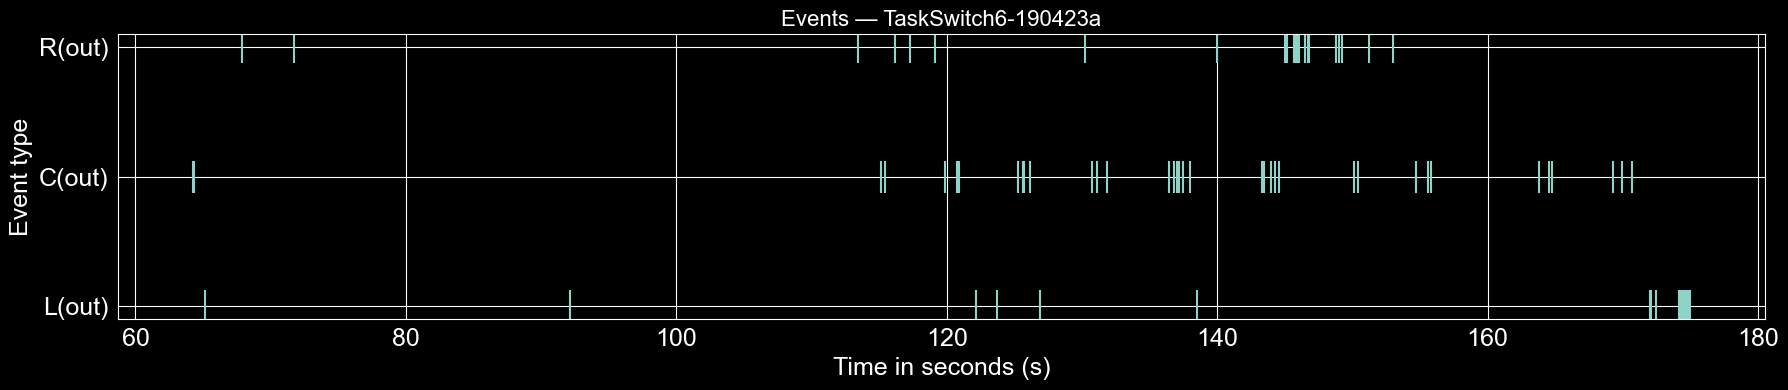

In [68]:
fig = plot_events(
    events=events[20:100],
    event_types=event_types,
    show_event_values=True,
    figsize=(18, 4),
    marker_size=500,
)
plt.title(f"Events — {nwbfile.session_id}", fontsize=16)
plt.tight_layout()
plt.show()

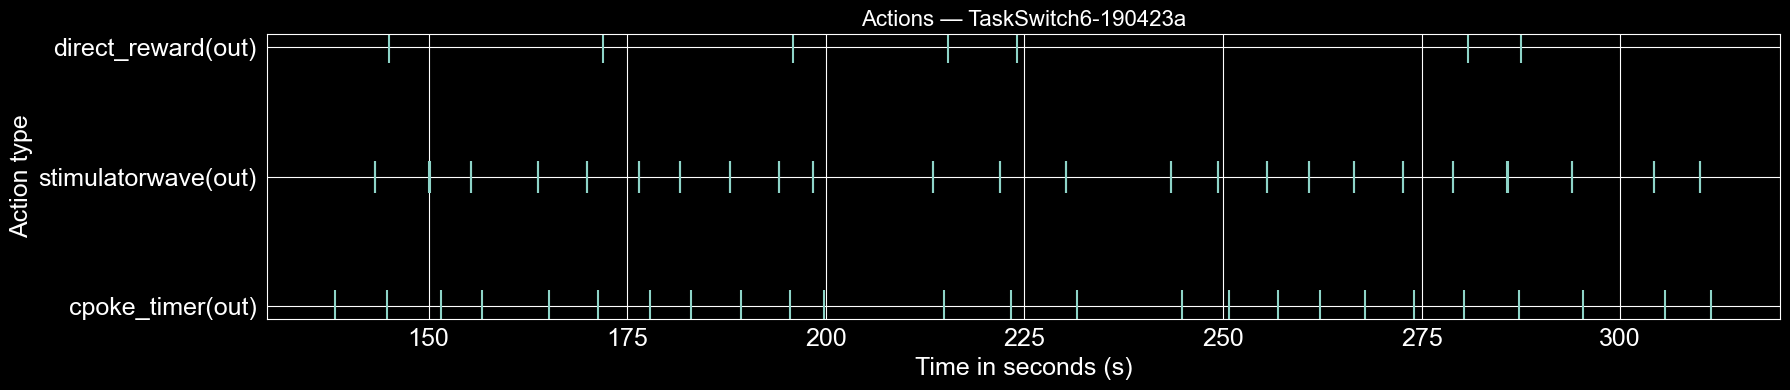

In [69]:
fig = plot_actions(
    actions=actions[20:100],
    action_types=action_types,
    figsize=(18, 4),
    marker_size=500,
)
plt.title(f"Actions — {nwbfile.session_id}", fontsize=16)
plt.tight_layout()
plt.show()

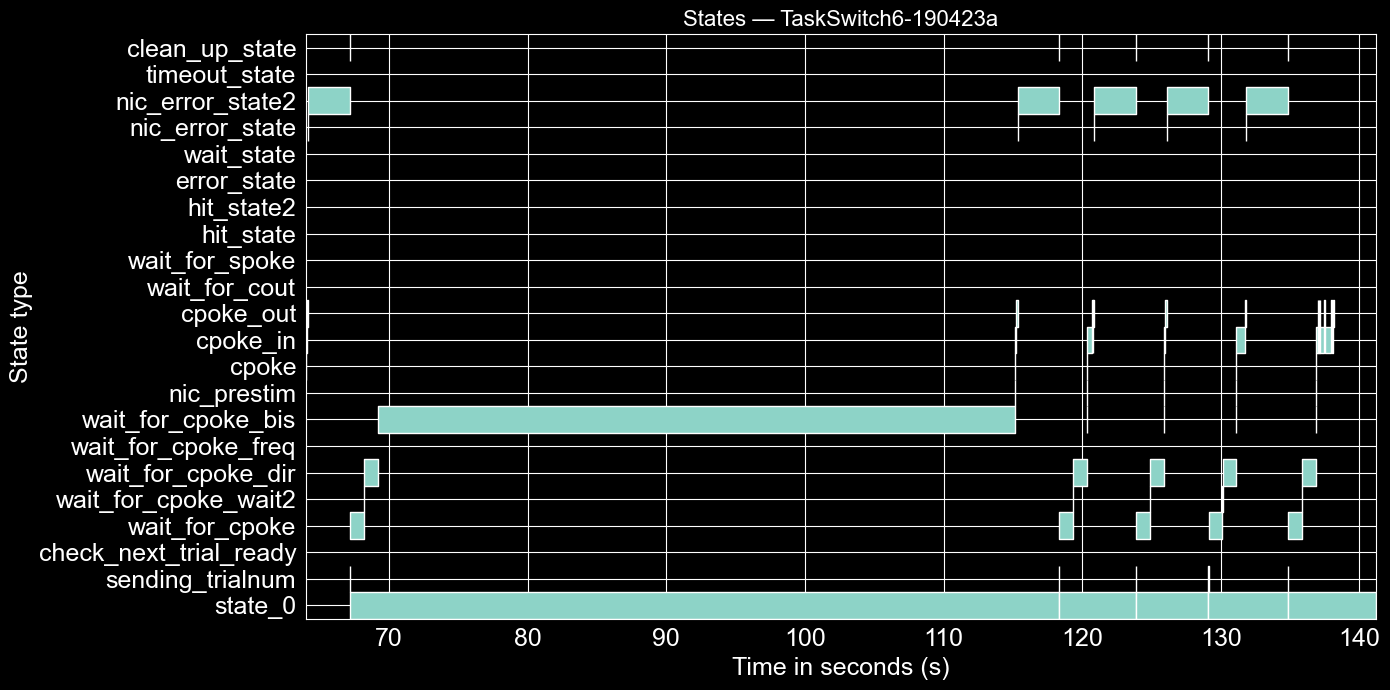

In [70]:
plot_states(
    figsize=(14, 7),
    states=states[20:100],
    state_types=state_types,
    marker_size=500,
)
plt.title(f"States — {nwbfile.session_id}", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Trials table

Each row in `nwbfile.trials` represents one completed trial. The table always contains `start_time`, `stop_time`, and per-trial history columns. TaskSwitch-family files also include stimulus scalar and pulse-time columns.

In [71]:
trials = nwbfile.trials
print(f"Number of trials : {len(trials)}")
print(f"Columns          : {list(trials.colnames)}")

Number of trials : 900
Columns          : ['start_time', 'stop_time', 'states', 'events', 'actions', 'cpoke_start_time', 'left_hi', 'right_hi', 'left_lo', 'right_lo', 'crosstalk_dir', 'crosstalk_freq', 'bup_width', 'bup_ramp', 'vol_low', 'vol_hi', 'vol', 'gamma_dir', 'gamma_freq', 'duration', 'freq_lo', 'freq_hi', 'HistorySection_hit_history', 'HistorySection_side_history', 'HistorySection_quadrant_history', 'HistorySection_task_history', 'HistorySection_incoh_history', 'HistorySection_gammadir_history', 'HistorySection_gammafreq_history', 'HistorySection_result_history']


In [72]:
pd.set_option("display.max_columns", None)

# Exclude ragged / region-reference columns that require special handling
REGION_COLS = {"left_hi", "right_hi", "left_lo", "right_lo", "states", "events", "actions"}
scalar_cols = [c for c in trials.colnames if c not in REGION_COLS]

trials[:5][scalar_cols]

,start_time,stop_time,cpoke_start_time,crosstalk_dir,crosstalk_freq,bup_width,bup_ramp,vol_low,vol_hi,vol,gamma_dir,gamma_freq,duration,freq_lo,freq_hi,HistorySection_hit_history,HistorySection_side_history,HistorySection_quadrant_history,HistorySection_task_history,HistorySection_incoh_history,HistorySection_gammadir_history,HistorySection_gammafreq_history,HistorySection_result_history
id,,,,,,,,,,,,,,,,,,,,,,,
0,52.710269,59.287265,56.146274,0,0,5,2,1,1,0.15,-1.0,2.5,1.3,6500,14200,NaN,l,3,d,1,-1.0,2.5,3
1,59.287771,67.177265,64.003770,0,0,5,2,1,1,0.15,-4.0,1.0,1.3,6500,14200,NaN,l,3,d,1,-4.0,1.0,3
2,67.177770,118.347265,115.138290,0,0,5,2,1,1,0.15,4.0,-1.0,1.3,6500,14200,NaN,r,1,d,1,4.0,-1.0,3
3,118.347765,123.885765,120.366770,0,0,5,2,1,1,0.15,2.5,-4.0,1.3,6500,14200,NaN,r,1,d,1,2.5,-4.0,3
4,123.886280,129.112281,125.904278,0,0,5,2,1,1,0.15,1.0,1.0,1.3,6500,14200,NaN,r,4,d,0,1.0,1.0,3


### Plot trial structure (states + events + actions per trial)

![Trials](trials.png)

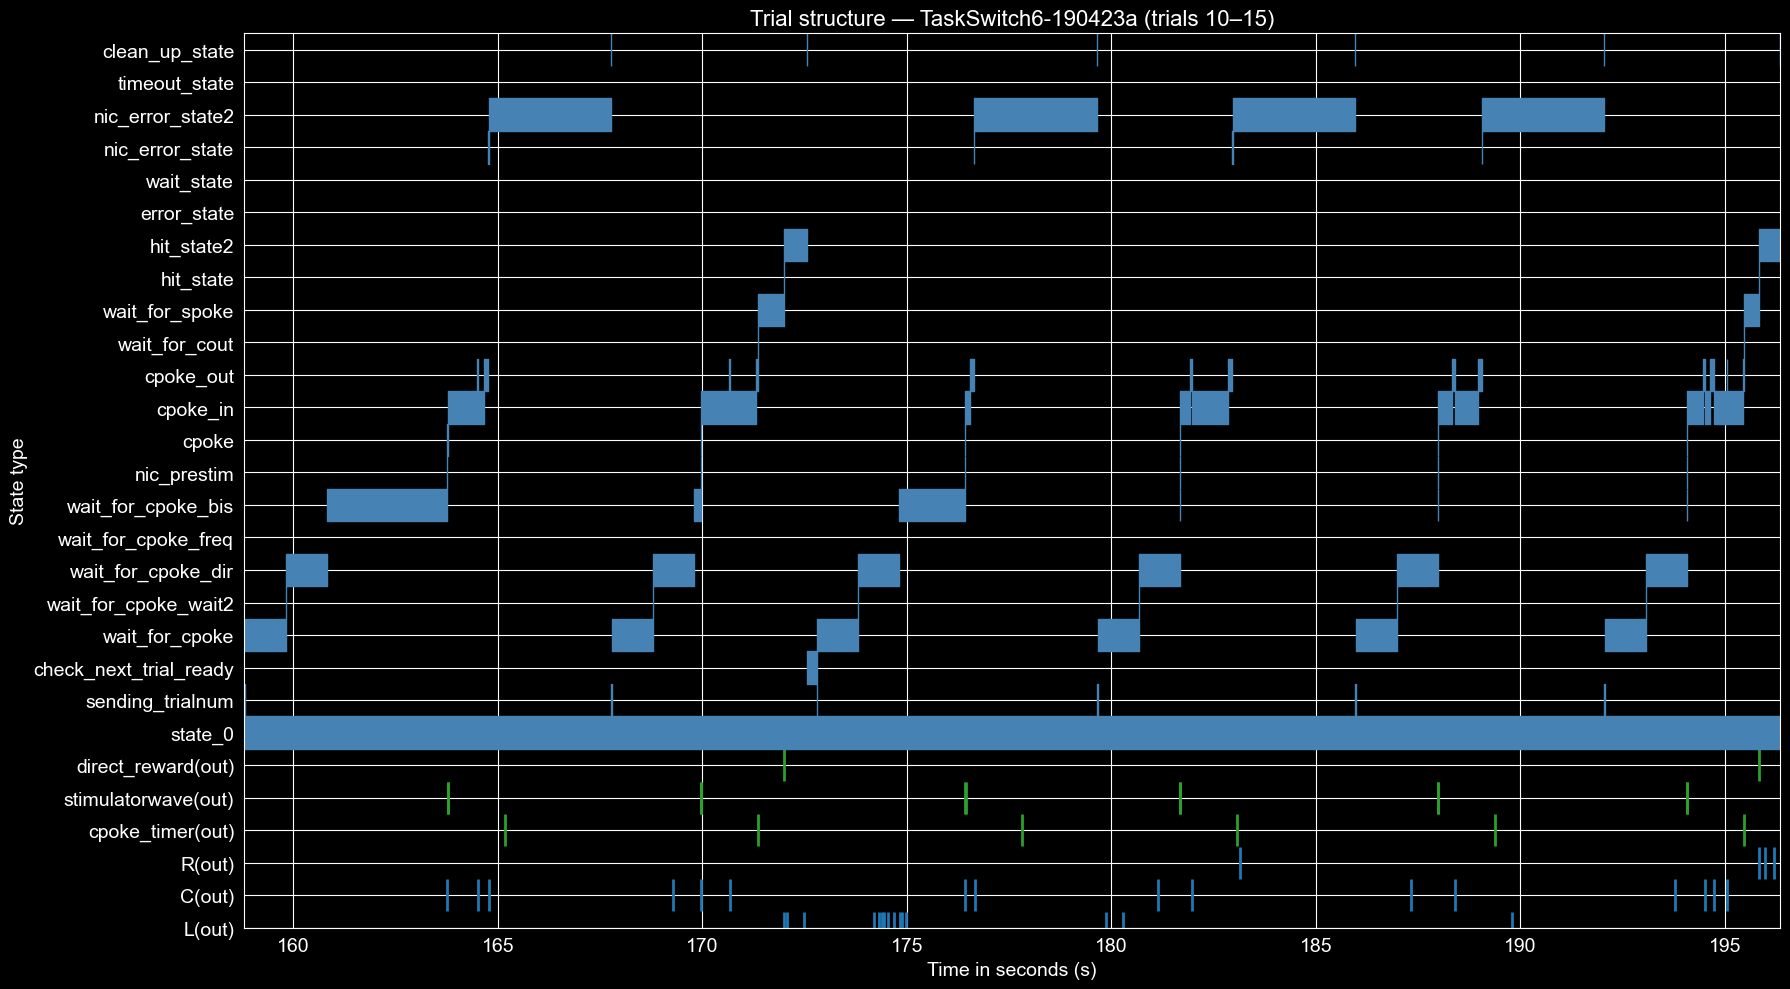

In [73]:
trials_df = trials[10:16]

fig = plt.figure(figsize=(18, 10))

# Events (blue ticks)
events_index = [j for i in trials_df["events"] for j in i]
if events_index:
    plot_events(events=events[events_index], event_types=event_types,
                show_event_values=True, marker_size=500, marker_width=2,
                marker_color="tab:blue", y_offset=0, fontsize=14, fig=fig)

# Actions (green ticks)
actions_index = [j for i in trials_df["actions"] for j in i]
y_offset = int(np.ceil(plt.ylim()[1]))
if y_offset == plt.ylim()[1]:
    y_offset += 1
if actions_index:
    plot_actions(actions=actions[actions_index], action_types=action_types,
                 show_action_values=True, marker_size=500, marker_width=2,
                 marker_color="tab:green", y_offset=y_offset, keep_yticks=True,
                 fontsize=14, fig=fig)

# States (steelblue rectangles — replaces hardcoded black)
states_index = [j for i in trials_df["states"] for j in i]
y_offset = int(np.ceil(plt.ylim()[1]))
if y_offset == plt.ylim()[1]:
    y_offset += 1
if states_index:
    plot_states(states=states[states_index], state_types=state_types,
                rectangle_color="steelblue", rectangle_height=1,
                marker_color="red", marker_size=500,
                y_offset=y_offset, keep_yticks=True, fontsize=14, fig=fig)

plt.title(f"Trial structure — {nwbfile.session_id} (trials 10–15)", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Protocol-specific: Stimulus data *(TaskSwitch family only)*

Files from the TaskSwitch protocol family include per-trial stimulus parameters:

- **Scalar columns**: `gamma_dir`, `gamma_freq`, `duration`, `freq_lo`, `freq_hi`, `vol`, `vol_low`, `vol_hi`, `bup_width`, `bup_ramp`, `crosstalk_dir`, `crosstalk_freq`
- **Ragged pulse columns**: `left_hi`, `right_hi`, `left_lo`, `right_lo` — lists of auditory pulse times, split by speaker side (left/right) and tone frequency (hi/lo)

### Pulse-time reference frame

Pulse times are stored **relative to cpoke onset** (the moment the rat entered the centre port), exactly as they come from BControl.  
A companion column `cpoke_start_time` gives the absolute time of cpoke onset in seconds from session start, so:

```
absolute_pulse_time = cpoke_start_time + pulse_time
```

`cpoke_start_time` is `NaN` for trials where the rat never poked (the stimulus was still generated, so relative pulse times are preserved).

Non-TaskSwitch files (PBups, ProAnti3, ProAnti3Marino) skip this section automatically.

In [74]:
STIMULUS_SCALAR_COLS = [
    "gamma_dir", "gamma_freq", "duration", "freq_lo", "freq_hi",
    "vol", "vol_low", "vol_hi", "bup_width", "bup_ramp",
    "crosstalk_dir", "crosstalk_freq",
]
PULSE_COLS = ["left_hi", "right_hi", "left_lo", "right_lo"]

has_stimulus = any(c in trials.colnames for c in STIMULUS_SCALAR_COLS)
has_pulses   = any(c in trials.colnames for c in PULSE_COLS)

print(f"Has stimulus cols : {has_stimulus}")
print(f"Has pulse cols    : {has_pulses}")

Has stimulus cols : True
Has pulse cols    : True


In [75]:
if has_stimulus:
    avail_scalar = [c for c in STIMULUS_SCALAR_COLS if c in trials.colnames]
    print(f"Stimulus scalar columns: {avail_scalar}")
    display(trials[:5][avail_scalar])
else:
    print("No stimulus columns in this session — skipping.")

Stimulus scalar columns: ['gamma_dir', 'gamma_freq', 'duration', 'freq_lo', 'freq_hi', 'vol', 'vol_low', 'vol_hi', 'bup_width', 'bup_ramp', 'crosstalk_dir', 'crosstalk_freq']


,gamma_dir,gamma_freq,duration,freq_lo,freq_hi,vol,vol_low,vol_hi,bup_width,bup_ramp,crosstalk_dir,crosstalk_freq
id,,,,,,,,,,,,
0,-1.0,2.5,1.3,6500,14200,0.15,1,1,5,2,0,0
1,-4.0,1.0,1.3,6500,14200,0.15,1,1,5,2,0,0
2,4.0,-1.0,1.3,6500,14200,0.15,1,1,5,2,0,0
3,2.5,-4.0,1.3,6500,14200,0.15,1,1,5,2,0,0
4,1.0,1.0,1.3,6500,14200,0.15,1,1,5,2,0,0


In [76]:
if has_pulses:
    trial_idx = 0
    cpoke_t = trials["cpoke_start_time"][trial_idx]
    print(f"Trial {trial_idx}  |  cpoke_start_time = {cpoke_t:.4f} s from session start")
    print()
    print(f"  {'column':12s}  {'n pulses':>8s}  {'first 4 (rel. to cpoke, s)':30s}  {'first 4 (abs. session time, s)'}")
    print(f"  {'-'*12}  {'-'*8}  {'-'*30}  {'-'*30}")
    for col in PULSE_COLS:
        if col not in trials.colnames:
            continue
        rel = np.array(trials[col][trial_idx])
        abs_ = rel + cpoke_t if not np.isnan(cpoke_t) else rel
        rel_preview  = str(np.round(rel[:4],  4).tolist()) + (" ..." if len(rel) > 4 else "")
        abs_preview  = str(np.round(abs_[:4], 4).tolist()) + (" ..." if len(abs_) > 4 else "")
        print(f"  {col:12s}  {len(rel):>8d}  {rel_preview:30s}  {abs_preview}")
else:
    print("No pulse-time columns in this session — skipping.")

Trial 0  |  cpoke_start_time = 56.1463 s from session start

  column        n pulses  first 4 (rel. to cpoke, s)      first 4 (abs. session time, s)
  ------------  --------  ------------------------------  ------------------------------
  left_hi             34  [0.0236, 0.1519, 0.1672, 0.1692] ...  [56.1699, 56.2981, 56.3135, 56.3155] ...
  right_hi            17  [0.0536, 0.0714, 0.3894, 0.3982] ...  [56.1999, 56.2177, 56.5357, 56.5444] ...
  left_lo              3  [0.039, 0.0563, 0.3522]         [56.1853, 56.2025, 56.4985]
  right_lo             4  [0.0184, 0.2052, 0.2583, 1.1511]  [56.1647, 56.3515, 56.4046, 57.2973]


### Pulse-time raster (first 10 trials)

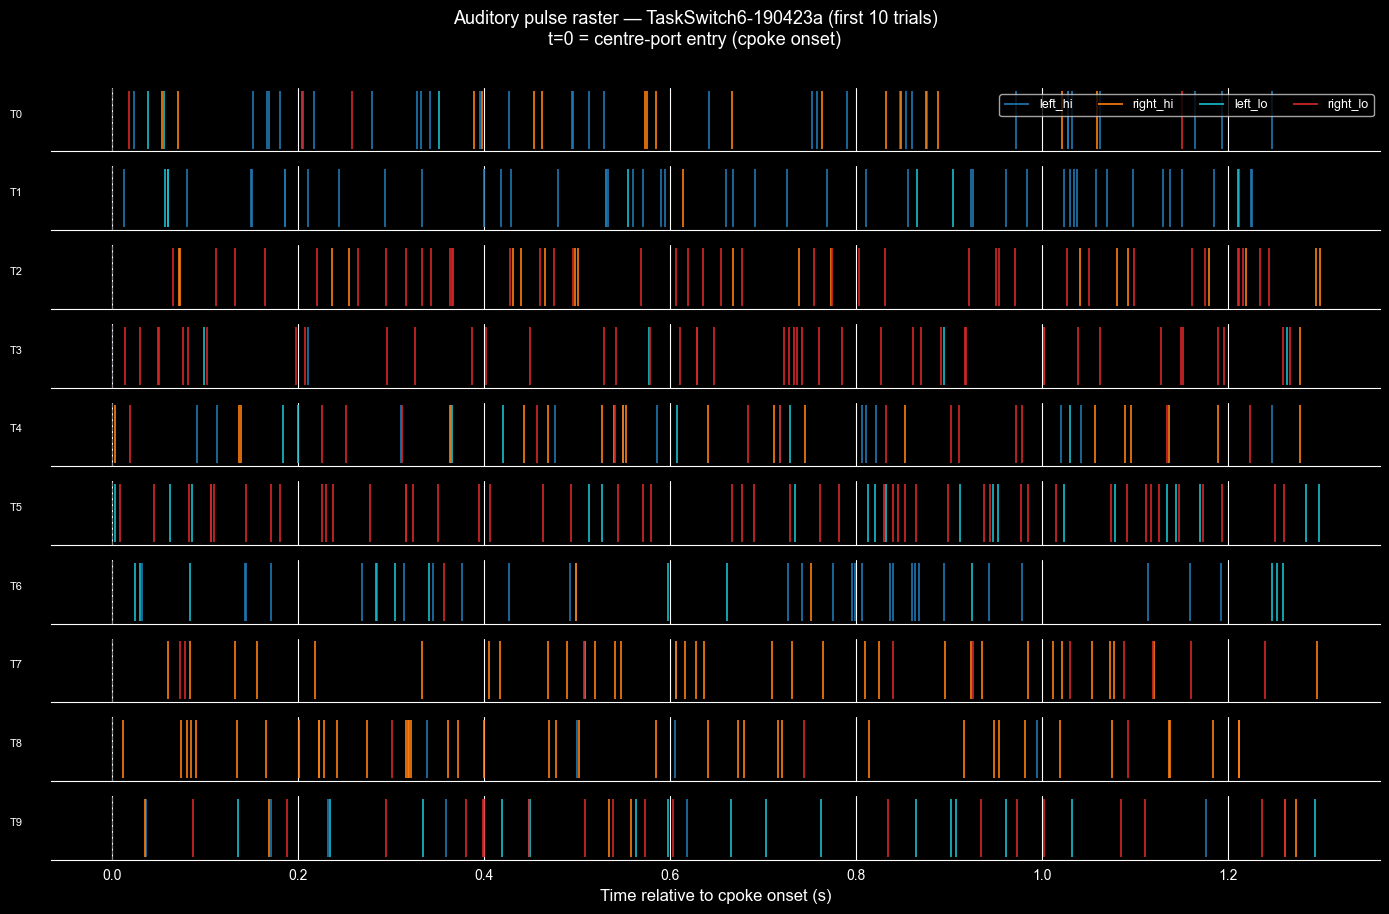

In [77]:
if has_pulses:
    N_TRIALS = 10
    colors = {
        "left_hi":  "tab:blue",
        "right_hi": "tab:orange",
        "left_lo":  "tab:cyan",
        "right_lo": "tab:red",
    }

    fig, axes = plt.subplots(N_TRIALS, 1, figsize=(14, N_TRIALS * 0.9), sharex=True)

    for trial_idx, ax in enumerate(axes):
        # Pulse times are already relative to cpoke onset — plot directly so
        # t=0 is cpoke entry on every trial (natural alignment point).
        for col, color in colors.items():
            if col not in trials.colnames:
                continue
            pulses = np.array(trials[col][trial_idx])
            if len(pulses) == 0:
                continue
            ax.vlines(pulses, 0, 1, color=color, linewidth=1.2,
                      label=col if trial_idx == 0 else None)
        ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")  # cpoke onset
        ax.set_ylabel(f"T{trial_idx}", fontsize=8, rotation=0, labelpad=25)
        ax.set_yticks([])
        ax.spines[["top", "right", "left"]].set_visible(False)

    axes[0].legend(loc="upper right", fontsize=9, ncol=4)
    axes[-1].set_xlabel("Time relative to cpoke onset (s)", fontsize=12)
    fig.suptitle(
        f"Auditory pulse raster — {nwbfile.session_id} (first {N_TRIALS} trials)\n"
        "t=0 = centre-port entry (cpoke onset)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No pulse-time columns in this session — skipping raster plot.")

## 7. Task arguments

`task.task_arguments` stores all session-level parameters from the BControl file (timing thresholds, reward amounts, protocol settings, etc.).

In [78]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 80)

task_args = task.task_arguments[:]
print(f"{len(task_args)} task arguments found")
task_args[["argument_name", "expression_type", "expression"]].head(20)

224 task arguments found


,argument_name,expression_type,expression
id,,,
0,ProtocolsSection_n_done_trials,integer,900
1,ProtocolsSection_n_started_trials,integer,901
2,ProtocolsSection_n_completed_trials,integer,900
3,TaskSwitch6_sessid,integer,689581
4,SavingSection_data_file,string,C:\ratter\SoloData\Data\Marino\P100\data_@TaskSwitch6_Marino_P100_190423_ASV...
5,SavingSection_settings_file_load_time,integer,0
6,SavingSection_experimenter,string,Marino
7,SavingSection_ratname,string,P100
8,SavingSection_hostname,string,localhost


In [79]:
task_args

,argument_name,argument_description,expression,expression_type,output_type
id,,,,,
0,ProtocolsSection_n_done_trials,The number of done trials.,900,integer,numeric
1,ProtocolsSection_n_started_trials,The number of started trials.,901,integer,numeric
2,ProtocolsSection_n_completed_trials,The number of completed trials.,900,integer,numeric
3,TaskSwitch6_sessid,no description,689581,integer,numeric
4,SavingSection_data_file,no description,C:\ratter\SoloData\Data\Marino\P100\data_@TaskSwitch6_Marino_P100_190423_ASV...,string,text
5,SavingSection_settings_file_load_time,no description,0,integer,numeric
6,SavingSection_experimenter,no description,Marino,string,text
7,SavingSection_ratname,no description,P100,string,text
8,SavingSection_hostname,no description,localhost,string,text


## 8. State transition analysis

How often is each state followed by each other state? The transition matrix and graph below summarise the session-level flow.

In [80]:
count_df, prob_df = compute_state_transition_matrix(states=states, state_types=state_types)

print("State transition count matrix (top-left corner):")
display(count_df.iloc[:8, :8])

State transition count matrix (top-left corner):


to,state_0,sending_trialnum,check_next_trial_ready,wait_for_cpoke,wait_for_cpoke_wait2,wait_for_cpoke_dir,wait_for_cpoke_freq,wait_for_cpoke_bis
from,,,,,,,,
state_0,0,662,0,238,0,0,0,0
sending_trialnum,238,0,0,662,0,0,0,0
check_next_trial_ready,228,82,0,0,0,0,0,0
wait_for_cpoke,0,0,0,0,902,0,0,0
wait_for_cpoke_wait2,0,0,0,0,0,493,409,0
wait_for_cpoke_dir,0,0,0,0,0,0,0,493
wait_for_cpoke_freq,0,0,0,0,0,0,0,409
wait_for_cpoke_bis,0,0,0,0,0,0,0,0


Dropped states : ['wait_for_cpoke_wait2', 'hit_state2', 'nic_error_state2']
Remaining      : ['state_0', 'sending_trialnum', 'check_next_trial_ready', 'wait_for_cpoke_dir', 'wait_for_cpoke_freq', 'wait_for_cpoke_bis', 'nic_prestim', 'cpoke', 'cpoke_in', 'cpoke_out', 'wait_for_cout', 'wait_for_spoke', 'error_state', 'timeout_state', 'clean_up_state']


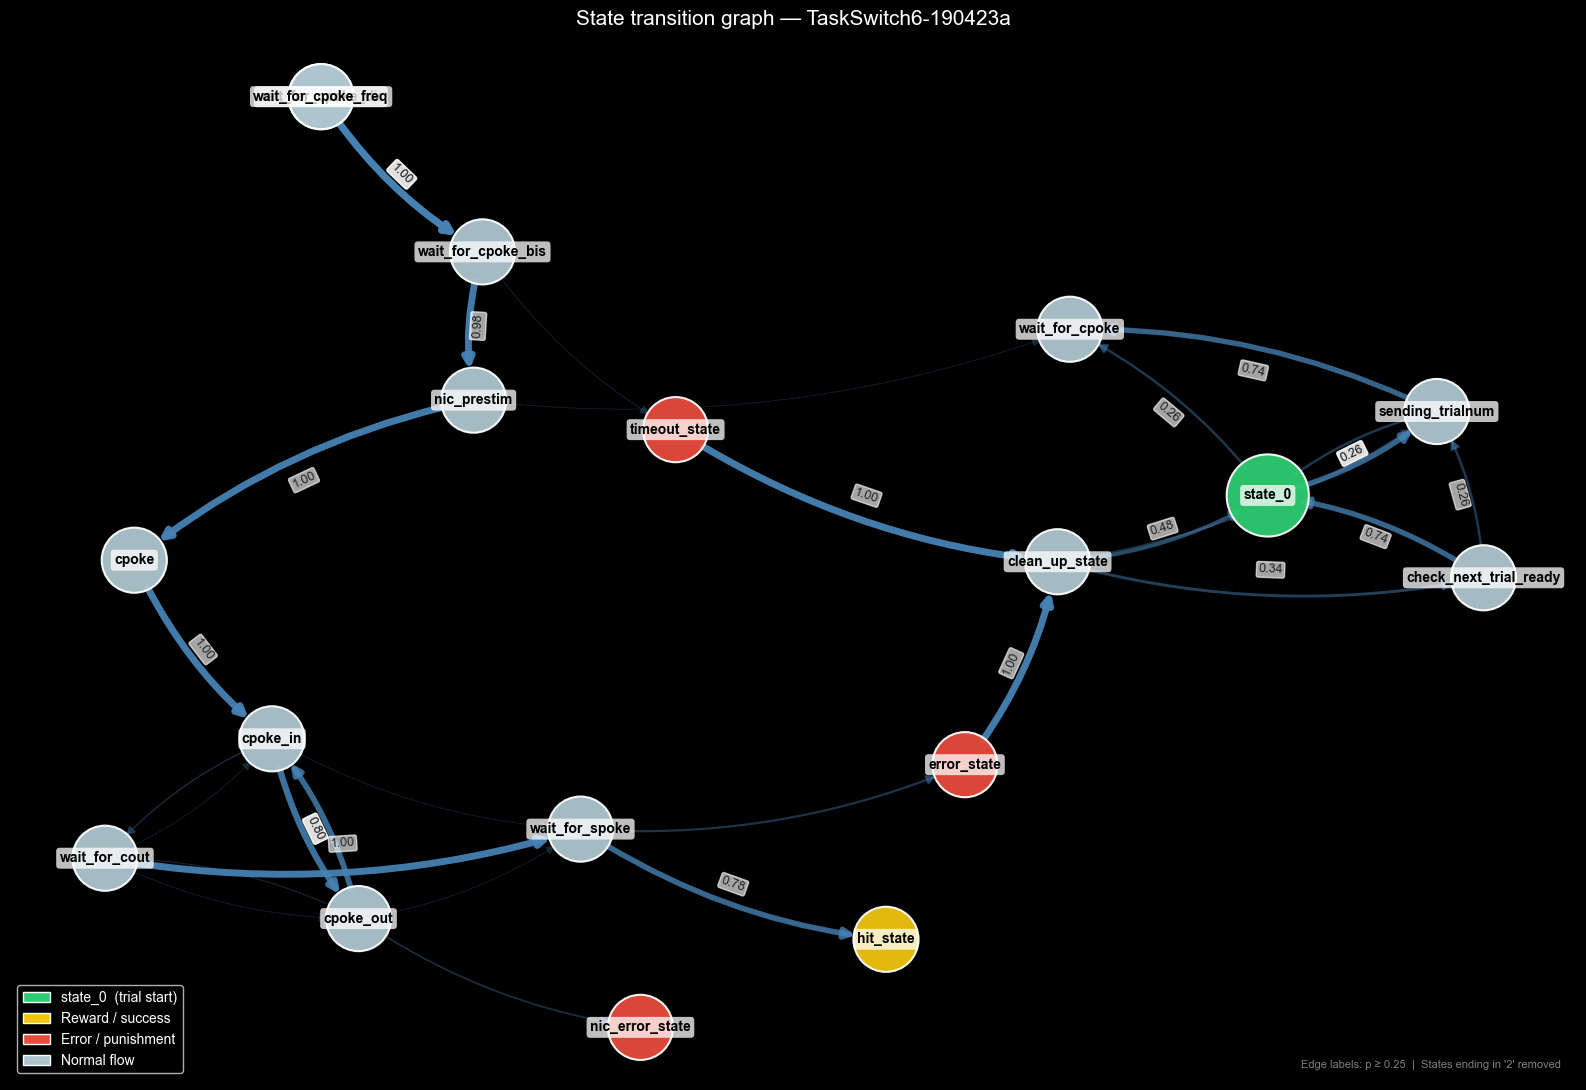

In [81]:
import networkx as nx
from matplotlib.patches import Patch

# ── Build base active matrix (drop all-zero rows/cols) ────────────────────────
mask   = (prob_df != 0).any(axis=1)
active = prob_df.loc[mask, prob_df.columns[(prob_df != 0).any(axis=0)]]

# ── Filter out continuation states that end with "2" ─────────────────────────
drop_states = [s for s in active.index if s.endswith("2")]
filtered = active.drop(
    index=drop_states,
    columns=[c for c in drop_states if c in active.columns],
    errors="ignore",
)
m2 = (filtered != 0).any(axis=1)
filtered = filtered.loc[m2, filtered.columns[(filtered != 0).any(axis=0)]]

print(f"Dropped states : {drop_states}")
print(f"Remaining      : {filtered.index.tolist()}")

# ── Build directed graph ──────────────────────────────────────────────────────
G = nx.DiGraph()
for src in filtered.index:
    for dst in filtered.columns:
        prob = filtered.loc[src, dst]
        if prob > 0:
            G.add_edge(src, dst, weight=prob)

# ── Node colours by semantic role ─────────────────────────────────────────────
REWARD_KW = {"hit", "reward", "drink", "soft_drink"}
ERROR_KW  = {"error", "violation", "punish", "timeout", "pun", "warning", "danger"}

def node_color(name):
    if name == "state_0":                          return "#2ecc71"  # green
    if any(k in name for k in REWARD_KW):          return "#f1c40f"  # gold
    if any(k in name for k in ERROR_KW):           return "#e74c3c"  # red
    return "#aec6cf"                                                  # blue-grey

node_colors = [node_color(n) for n in G.nodes()]
node_sizes  = [3500 if n == "state_0" else 2200 for n in G.nodes()]

# ── Layout ────────────────────────────────────────────────────────────────────
try:
    pos = nx.kamada_kawai_layout(G, weight=None)
except Exception:
    pos = nx.spring_layout(G, seed=42, k=2.0)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))

# 1. Nodes first
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes,
    edgecolors="white", linewidths=1.5, alpha=0.95,
)

# 2. Edges — width and alpha scale with probability
all_weights = [d["weight"] for _, _, d in G.edges(data=True)]
max_w = max(all_weights) if all_weights else 1.0

for src, dst, data in G.edges(data=True):
    w = data["weight"]
    nx.draw_networkx_edges(
        G, pos, edgelist=[(src, dst)], ax=ax,
        width=0.6 + 4.4 * w / max_w,
        alpha=0.25 + 0.70 * w / max_w,
        edge_color="steelblue",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
        connectionstyle="arc3,rad=0.12",
        min_source_margin=22,
        min_target_margin=22,
    )

# 3. Edge labels (dominant transitions only)
LABEL_THRESHOLD = 0.25
edge_labels = {
    (src, dst): f"{data['weight']:.2f}"
    for src, dst, data in G.edges(data=True)
    if data["weight"] >= LABEL_THRESHOLD
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, ax=ax,
    font_size=9, font_color="#222222",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.65),
)

# 4. Node labels LAST — drawn on top of everything with an opaque white backing
#    so edges passing through a node center cannot bleed into the text.
for node, (x, y) in pos.items():
    ax.text(
        x, y, node,
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75),
        zorder=5,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor="#2ecc71", label="state_0  (trial start)"),
    Patch(facecolor="#f1c40f", label="Reward / success"),
    Patch(facecolor="#e74c3c", label="Error / punishment"),
    Patch(facecolor="#aec6cf", label="Normal flow"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10, framealpha=0.85)
ax.text(
    0.99, 0.01,
    f"Edge labels: p ≥ {LABEL_THRESHOLD}  |  States ending in '2' removed",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="gray",
)
ax.set_title(f"State transition graph — {nwbfile.session_id}", fontsize=15, pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()